In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving results.csv to results.csv


In [3]:
df = pd.read_csv("results.csv")

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (49493, 9)


In [5]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49493 entries, 0 to 49492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49493 non-null  object 
 1   home_team   49493 non-null  object 
 2   away_team   49493 non-null  object 
 3   home_score  49477 non-null  float64
 4   away_score  49477 non-null  float64
 5   tournament  49493 non-null  object 
 6   city        49493 non-null  object 
 7   country     49493 non-null  object 
 8   neutral     49493 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [7]:
df.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,16
away_score,16
tournament,0
city,0
country,0
neutral,0


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (49493, 9)


In [10]:
df.sample(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41657,2018-06-20,Uruguay,Saudi Arabia,1.0,0.0,FIFA World Cup,Rostov-on-Don,Russia,True
11088,1977-08-24,Austria,Poland,2.0,1.0,Friendly,Vienna,Austria,False
43764,2021-03-24,Rwanda,Mozambique,1.0,0.0,African Cup of Nations qualification,Kigali,Rwanda,False
27946,2004-02-18,Cyprus,Belarus,0.0,2.0,Cyprus International Tournament,Dasaki Achnas,Cyprus,False
20208,1995-03-26,Montserrat,Anguilla,3.0,2.0,CFU Caribbean Cup qualification,Plymouth,Montserrat,False
34009,2010-09-03,England,Bulgaria,4.0,0.0,UEFA Euro qualification,London,England,False
30043,2006-06-11,Mexico,Iran,3.0,1.0,FIFA World Cup,Nuremberg,Germany,True
32960,2009-05-31,Malawi,Rwanda,2.0,0.0,Friendly,Blantyre,Malawi,False
4642,1958-04-30,Argentina,Uruguay,2.0,0.0,Friendly,Buenos Aires,Argentina,False
18775,1993-02-13,United States,Russia,0.0,1.0,Friendly,Orlando,United States,False


In [11]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [12]:
df.dtypes

,0
date,object
home_team,object
away_team,object
home_score,float64
away_score,float64
tournament,object
city,object
country,object
neutral,bool


In [13]:
df["tournament"].value_counts().head(20)

,count
tournament,
Friendly,18388
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,1052
Copa América,869
African Cup of Nations,845
AFC Asian Cup qualification,829
UEFA Nations League,658


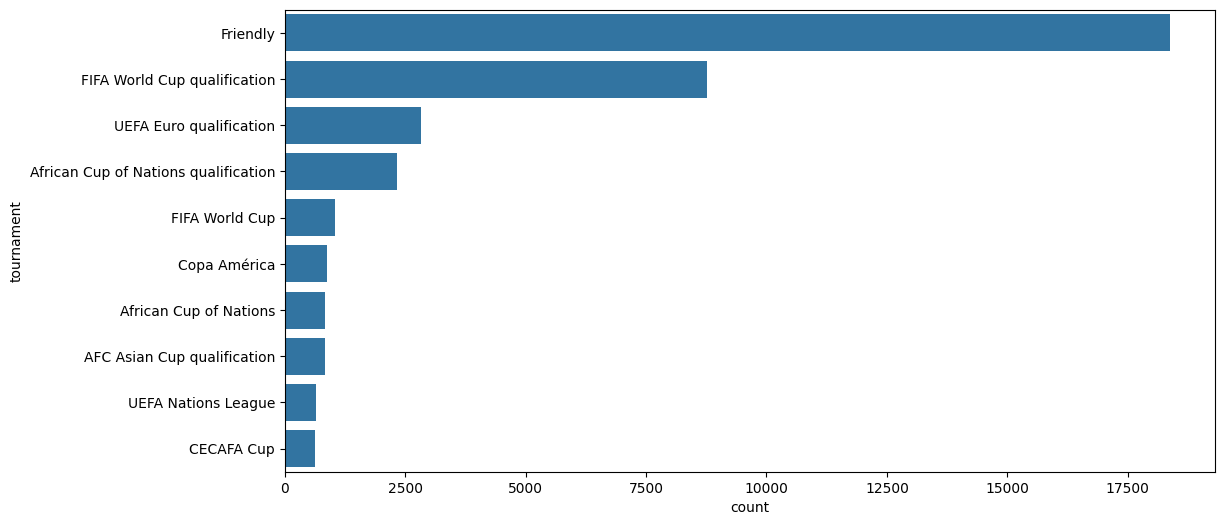

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(y=df["tournament"], order=df["tournament"].value_counts().head(10).index)
plt.show()

In [15]:
df["home_score"].describe()

,home_score
count,49477.000000
mean,1.757322
std,1.774094
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,31.000000


In [16]:
df["away_score"].describe()

,away_score
count,49477.000000
mean,1.181923
std,1.401793
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,21.000000


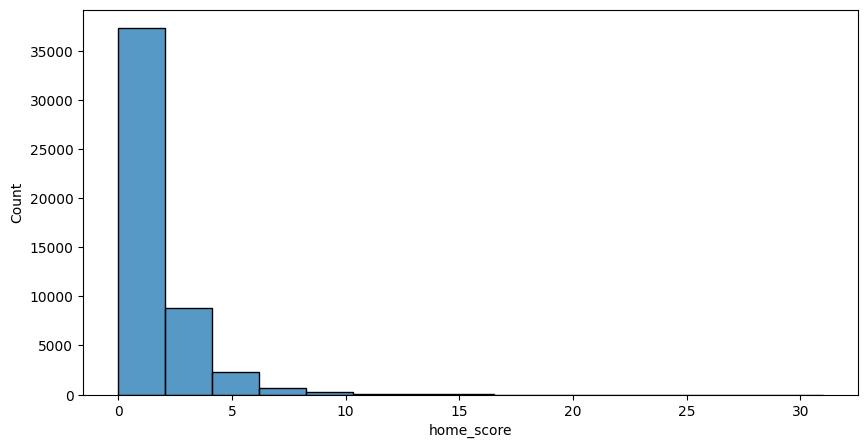

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df["home_score"], bins=15)
plt.show()

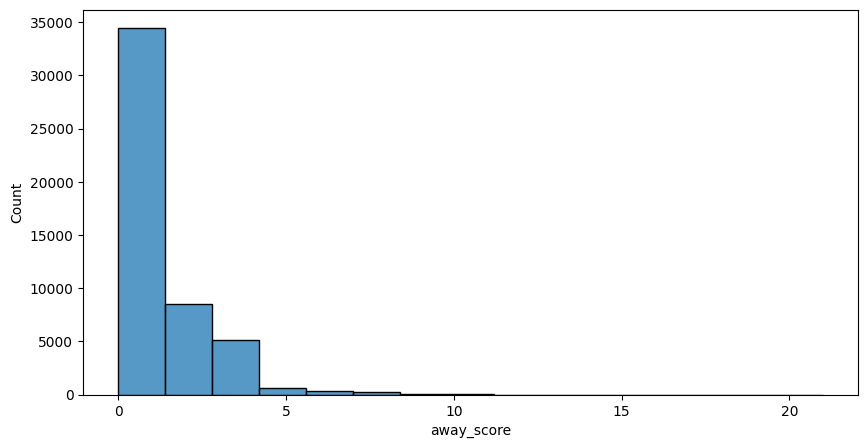

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df["away_score"], bins=15)
plt.show()

In [19]:
df["winner"] = np.where(
    df["home_score"] > df["away_score"],
    "Home",
    np.where(df["home_score"] < df["away_score"], "Away", "Draw")
)

In [20]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Home
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Home
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Home


In [21]:
df["winner"].value_counts()

,count
winner,
Home,24245
Away,13979
Draw,11269


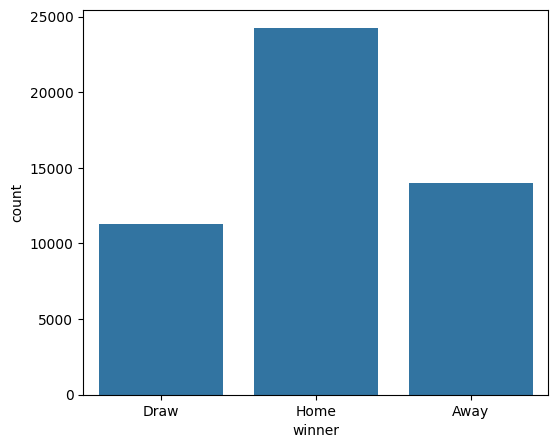

In [22]:
plt.figure(figsize=(6,5))
sns.countplot(x=df["winner"])
plt.show()

In [23]:
home_wins = df[df["winner"]=="Home"]["home_team"].value_counts().head(15)

home_wins

,count
home_team,
Brazil,439
Argentina,410
Mexico,355
Germany,346
England,343
South Korea,330
France,319
Sweden,315
Italy,310


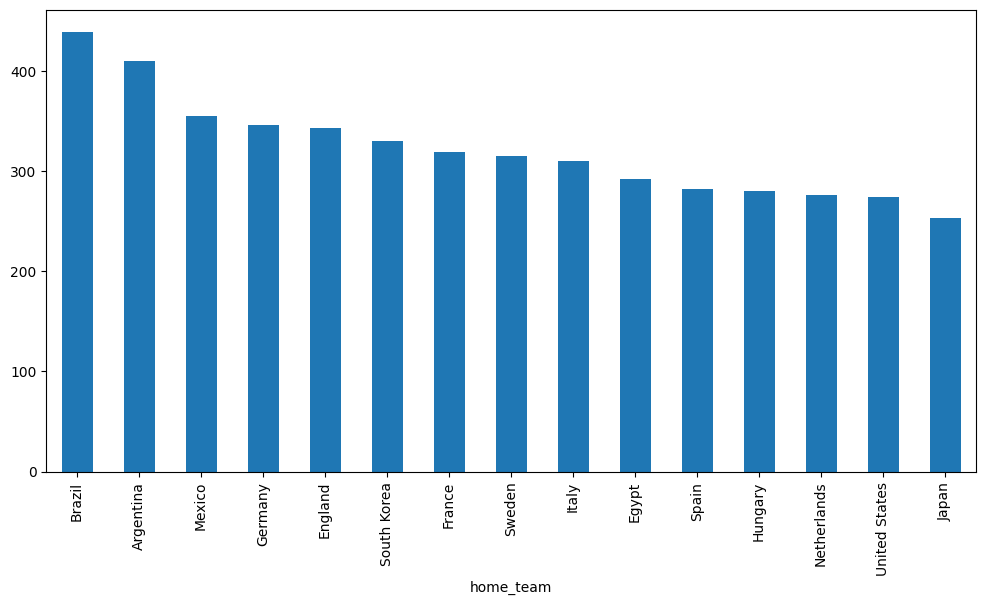

In [24]:
plt.figure(figsize=(12,6))
home_wins.plot(kind="bar")
plt.show()

In [25]:
away_wins = df[df["winner"]=="Away"]["away_team"].value_counts().head(15)

away_wins

,count
away_team,
England,284
Germany,255
Brazil,235
Sweden,227
South Korea,209
Uruguay,208
Hungary,192
Argentina,185
Russia,181


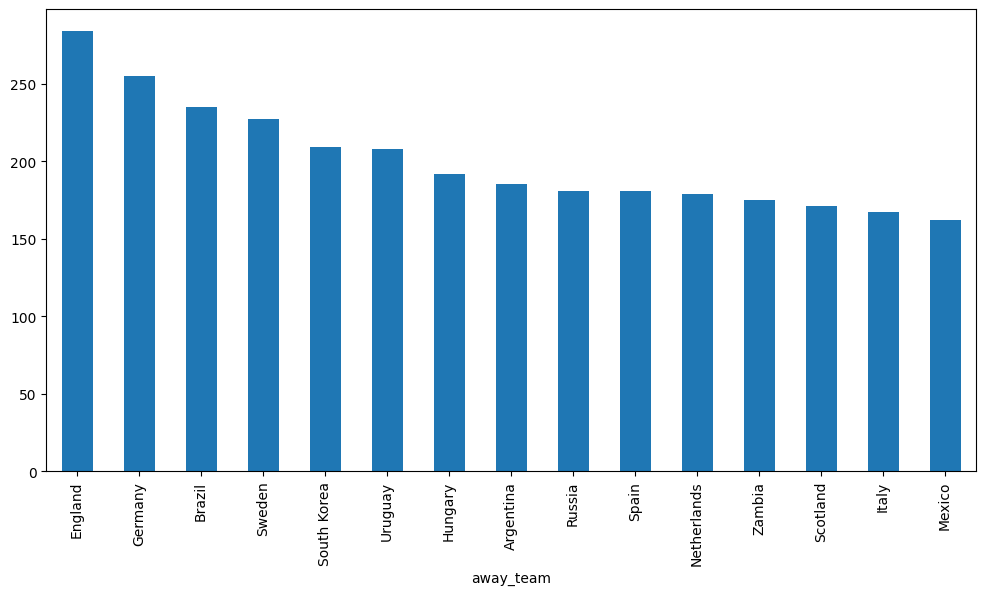

In [26]:
plt.figure(figsize=(12,6))
away_wins.plot(kind="bar")
plt.show()

In [27]:
df["total_goals"] = df["home_score"] + df["away_score"]

df["total_goals"].describe()

,total_goals
count,49477.000000
mean,2.939244
std,2.095164
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,31.000000


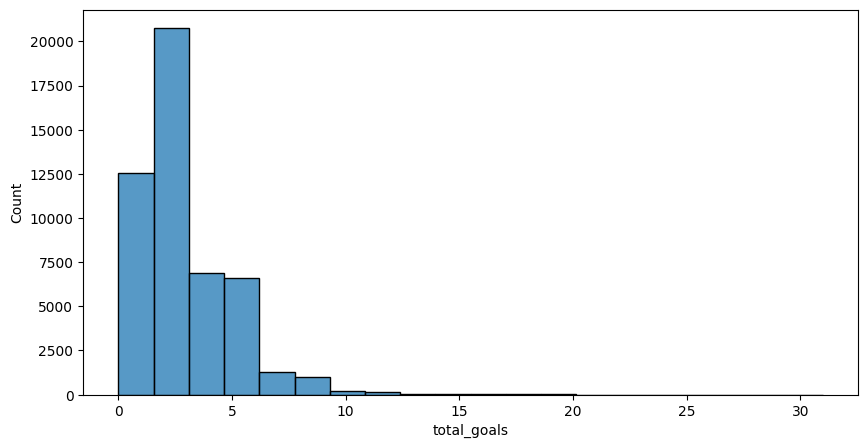

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df["total_goals"], bins=20)
plt.show()

In [29]:
df.sort_values("total_goals", ascending=False).head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,total_goals
25425,2001-04-11,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,False,Home,31.0
8551,1971-09-13,Tahiti,Cook Islands,30.0,0.0,South Pacific Games,Papeete,Tahiti,False,Home,30.0
11916,1979-08-30,Fiji,Kiribati,24.0,0.0,South Pacific Games,Nausori,Fiji,False,Home,24.0
30518,2006-11-24,Sápmi,Monaco,21.0,1.0,Viva World Cup,Hyères,France,True,Home,22.0
25422,2001-04-09,Australia,Tonga,22.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,False,Home,22.0
37061,2013-06-24,Provence,Tibet,22.0,0.0,"International Tournament of Peoples, Cultures ...",Marseille,France,False,Home,22.0
29045,2005-03-11,Guam,North Korea,0.0,21.0,EAFF Championship,Taipei,Taiwan,True,Away,21.0
21957,1997-05-13,Kazakhstan,Guam,20.0,1.0,East Asian Games,Busan,South Korea,True,Home,21.0
37059,2013-06-23,Quebec,Tibet,21.0,0.0,"International Tournament of Peoples, Cultures ...",Marseille,France,True,Home,21.0
6580,1966-04-03,Libya,Oman,21.0,0.0,Arab Cup,Baghdad,Iraq,True,Home,21.0


In [30]:
teams = pd.concat([df["home_team"], df["away_team"]])

teams.value_counts().head(20)

,count
Sweden,1105
England,1094
Argentina,1073
Brazil,1063
Germany,1035
South Korea,1010
Mexico,1007
Hungary,1006
Uruguay,973
France,939


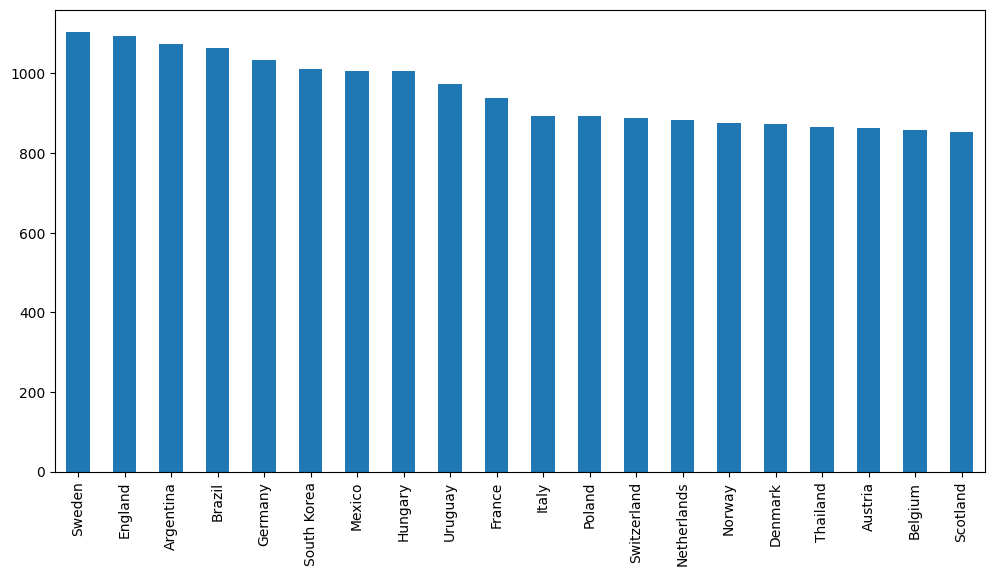

In [31]:
plt.figure(figsize=(12,6))
teams.value_counts().head(20).plot(kind="bar")
plt.show()

In [32]:
X = df[["home_team", "away_team", "tournament", "neutral"]]

y = df["winner"]

In [33]:
X.head()

,home_team,away_team,tournament,neutral
0,Scotland,England,Friendly,False
1,England,Scotland,Friendly,False
2,Scotland,England,Friendly,False
3,England,Scotland,Friendly,False
4,Scotland,England,Friendly,False


In [34]:
from sklearn.preprocessing import LabelEncoder

home_encoder = LabelEncoder()
away_encoder = LabelEncoder()
tournament_encoder = LabelEncoder()
winner_encoder = LabelEncoder()

In [35]:
X["home_team"] = home_encoder.fit_transform(X["home_team"])

X["away_team"] = away_encoder.fit_transform(X["away_team"])

X["tournament"] = tournament_encoder.fit_transform(X["tournament"])

X["neutral"] = X["neutral"].astype(int)

y = winner_encoder.fit_transform(y)

In [36]:
X.head()

,home_team,away_team,tournament,neutral
0,250,88,94,0
1,86,245,94,0
2,250,88,94,0
3,86,245,94,0
4,250,88,94,0


In [37]:
y[:10]

array([1, 2, 2, 1, 2, 2, 0, 0, 2, 2])

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(39594, 4)
(9899, 4)


In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
y_pred_lr = lr.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.4921709263561976

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2759
           1       0.00      0.00      0.00      2267
           2       0.49      1.00      0.66      4873

    accuracy                           0.49      9899
   macro avg       0.16      0.33      0.22      9899
weighted avg       0.24      0.49      0.32      9899



In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[   0,    0, 2759],
       [   0,    0, 2267],
       [   1,    0, 4872]])

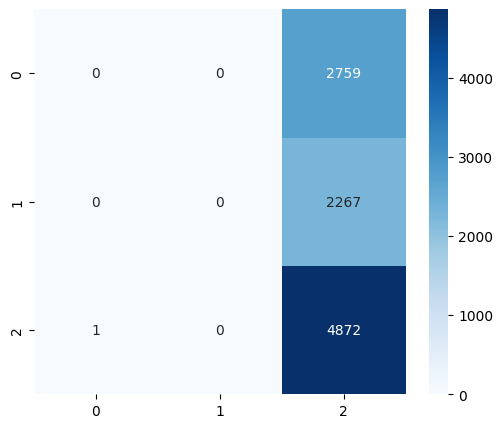

In [45]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
y_pred_dt = dt.predict(X_test)

In [48]:
accuracy_score(y_test, y_pred_dt)

0.4591372865946055

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [50]:
y_pred_rf = rf.predict(X_test)

In [51]:
accuracy_score(y_test, y_pred_rf)

0.497322961915345

In [52]:
models = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.492171
1,Decision Tree,0.459137
2,Random Forest,0.497323


In [53]:
models.sort_values("Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.497323
0,Logistic Regression,0.492171
1,Decision Tree,0.459137


In [54]:
team_stats = {}

teams = pd.concat([df["home_team"], df["away_team"]]).unique()

for team in teams:
    home = df[df["home_team"] == team]
    away = df[df["away_team"] == team]

    matches = len(home) + len(away)

    wins = (
        len(home[home["home_score"] > home["away_score"]]) +
        len(away[away["away_score"] > away["home_score"]])
    )

    goals_scored = home["home_score"].sum() + away["away_score"].sum()

    goals_conceded = home["away_score"].sum() + away["home_score"].sum()

    team_stats[team] = {
        "matches": matches,
        "wins": wins,
        "win_rate": wins / matches,
        "goals_scored": goals_scored / matches,
        "goals_conceded": goals_conceded / matches
    }

In [55]:
team_stats["Argentina"]

{'matches': 1073,
 'wins': 595,
 'win_rate': 0.554520037278658,
 'goals_scored': np.float64(1.8974836905871388),
 'goals_conceded': np.float64(1.0027958993476236)}

In [56]:
strength = pd.DataFrame(team_stats).T

strength.head()

,matches,wins,win_rate,goals_scored,goals_conceded
Scotland,854.0,403.0,0.471897,1.703747,1.234192
England,1094.0,627.0,0.573126,2.181901,0.953382
Wales,726.0,234.0,0.322314,1.253444,1.597796
Northern Ireland,707.0,185.0,0.261669,1.048091,1.833098
United States,794.0,353.0,0.444584,1.521411,1.324937


In [57]:
strength.sort_values("win_rate", ascending=False).head(20)

,matches,wins,win_rate,goals_scored,goals_conceded
Elba Island,2.0,2.0,1.000000,4.500000,1.000000
Surrey,1.0,1.0,1.000000,3.000000,1.000000
Asturias,1.0,1.0,1.000000,3.000000,1.000000
Maule Sur,2.0,2.0,1.000000,1.000000,0.000000
Kurdistan,5.0,4.0,0.800000,2.400000,0.400000
Canary Islands,4.0,3.0,0.750000,2.750000,0.750000
Yorkshire,7.0,5.0,0.714286,3.857143,1.571429
County of Nice,9.0,6.0,0.666667,2.111111,1.444444
Parishes of Jersey,3.0,2.0,0.666667,3.666667,1.333333
Franconia,3.0,2.0,0.666667,2.666667,3.666667


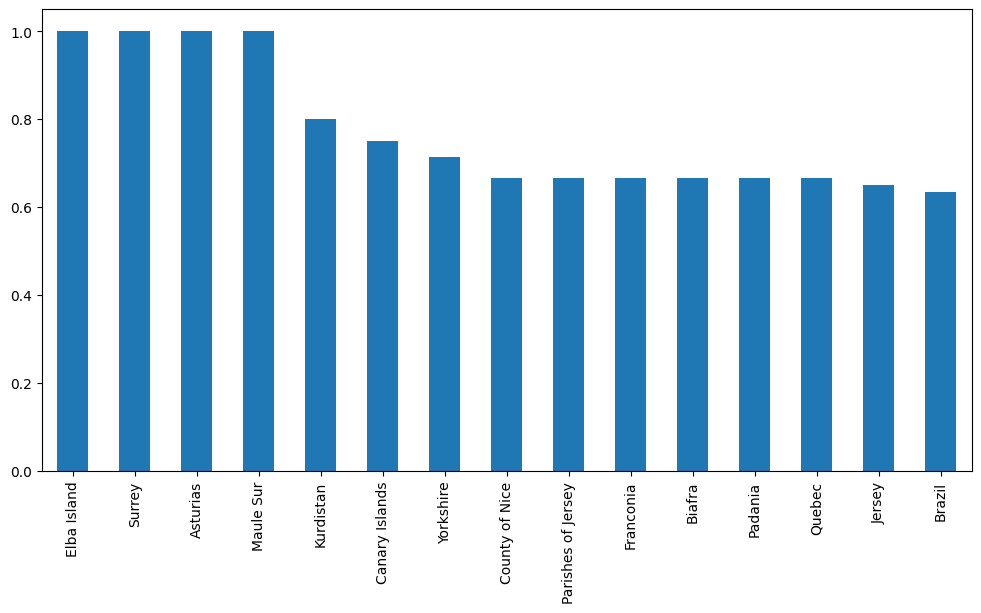

In [58]:
plt.figure(figsize=(12,6))
strength.sort_values("win_rate", ascending=False).head(15)["win_rate"].plot(kind="bar")
plt.show()

In [59]:
strength["score"] = (
    strength["win_rate"] * 0.6 +
    strength["goals_scored"] * 0.3 -
    strength["goals_conceded"] * 0.1
)

In [60]:
strength = strength.sort_values("score", ascending=False)

strength.head(10)

,matches,wins,win_rate,goals_scored,goals_conceded,score
Quebec,3.0,2.0,0.666667,8.000000,0.666667,2.733333
Elba Island,2.0,2.0,1.000000,4.500000,1.000000,1.850000
Yorkshire,7.0,5.0,0.714286,3.857143,1.571429,1.428571
Surrey,1.0,1.0,1.000000,3.000000,1.000000,1.400000
Asturias,1.0,1.0,1.000000,3.000000,1.000000,1.400000
Parishes of Jersey,3.0,2.0,0.666667,3.666667,1.333333,1.366667
Canary Islands,4.0,3.0,0.750000,2.750000,0.750000,1.200000
Isle of Man,58.0,35.0,0.603448,3.206897,1.500000,1.174138
Occitania,33.0,19.0,0.575758,3.121212,1.151515,1.166667
Kurdistan,5.0,4.0,0.800000,2.400000,0.400000,1.160000


In [61]:
winner = strength.index[0]

print("Predicted FIFA World Cup 2026 Winner:")
print(winner)

Predicted FIFA World Cup 2026 Winner:
Quebec


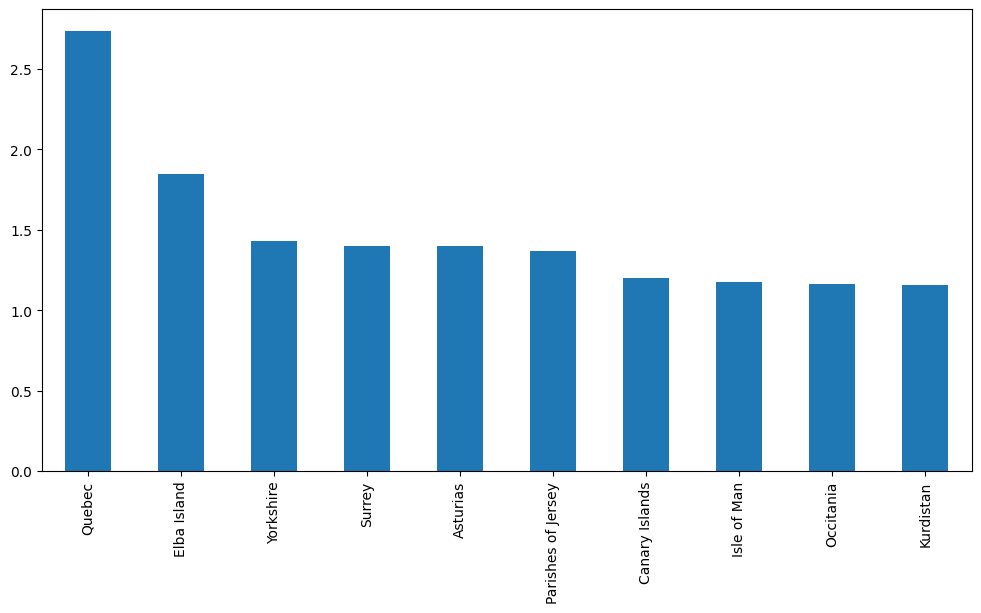

In [62]:
plt.figure(figsize=(12,6))
strength.head(10)["score"].plot(kind="bar")
plt.show()

In [63]:
ml_df = df.copy()

In [64]:
ml_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,total_goals
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw,0.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Home,6.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Home,3.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw,4.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Home,3.0


In [65]:
ml_df["home_win_rate"] = ml_df["home_team"].map(lambda x: team_stats[x]["win_rate"])
ml_df["away_win_rate"] = ml_df["away_team"].map(lambda x: team_stats[x]["win_rate"])

ml_df["home_goals_scored"] = ml_df["home_team"].map(lambda x: team_stats[x]["goals_scored"])
ml_df["away_goals_scored"] = ml_df["away_team"].map(lambda x: team_stats[x]["goals_scored"])

ml_df["home_goals_conceded"] = ml_df["home_team"].map(lambda x: team_stats[x]["goals_conceded"])
ml_df["away_goals_conceded"] = ml_df["away_team"].map(lambda x: team_stats[x]["goals_conceded"])

In [66]:
ml_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,total_goals,home_win_rate,away_win_rate,home_goals_scored,away_goals_scored,home_goals_conceded,away_goals_conceded
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,Draw,0.0,0.471897,0.573126,1.703747,2.181901,1.234192,0.953382
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,Home,6.0,0.573126,0.471897,2.181901,1.703747,0.953382,1.234192
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,Home,3.0,0.471897,0.573126,1.703747,2.181901,1.234192,0.953382
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,Draw,4.0,0.573126,0.471897,2.181901,1.703747,0.953382,1.234192
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,Home,3.0,0.471897,0.573126,1.703747,2.181901,1.234192,0.953382


In [67]:
ml_df["winner"] = np.where(
    ml_df["home_score"] > ml_df["away_score"],
    0,
    np.where(
        ml_df["home_score"] < ml_df["away_score"],
        1,
        2
    )
)

In [68]:
X = ml_df[
    [
        "home_win_rate",
        "away_win_rate",
        "home_goals_scored",
        "away_goals_scored",
        "home_goals_conceded",
        "away_goals_conceded",
        "neutral"
    ]
]

y = ml_df["winner"]

In [69]:
X.head()

,home_win_rate,away_win_rate,home_goals_scored,away_goals_scored,home_goals_conceded,away_goals_conceded,neutral
0,0.471897,0.573126,1.703747,2.181901,1.234192,0.953382,False
1,0.573126,0.471897,2.181901,1.703747,0.953382,1.234192,False
2,0.471897,0.573126,1.703747,2.181901,1.234192,0.953382,False
3,0.573126,0.471897,2.181901,1.703747,0.953382,1.234192,False
4,0.471897,0.573126,1.703747,2.181901,1.234192,0.953382,False


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [72]:
y_pred = rf.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5348014951005152

In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.73      0.67      4873
           1       0.50      0.50      0.50      2759
           2       0.26      0.16      0.20      2267

    accuracy                           0.53      9899
   macro avg       0.46      0.46      0.46      9899
weighted avg       0.50      0.53      0.52      9899



In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[3546,  717,  610],
       [ 911, 1377,  471],
       [1236,  660,  371]])

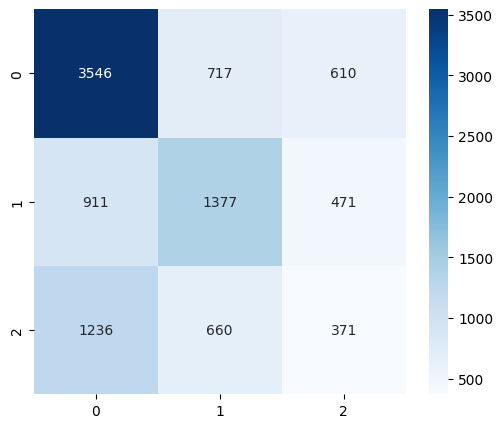

In [76]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

In [77]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values("Importance", ascending=False)

,Feature,Importance
0,home_win_rate,0.173019
1,away_win_rate,0.167263
4,home_goals_conceded,0.161717
5,away_goals_conceded,0.153819
2,home_goals_scored,0.144677
3,away_goals_scored,0.141807
6,neutral,0.057699


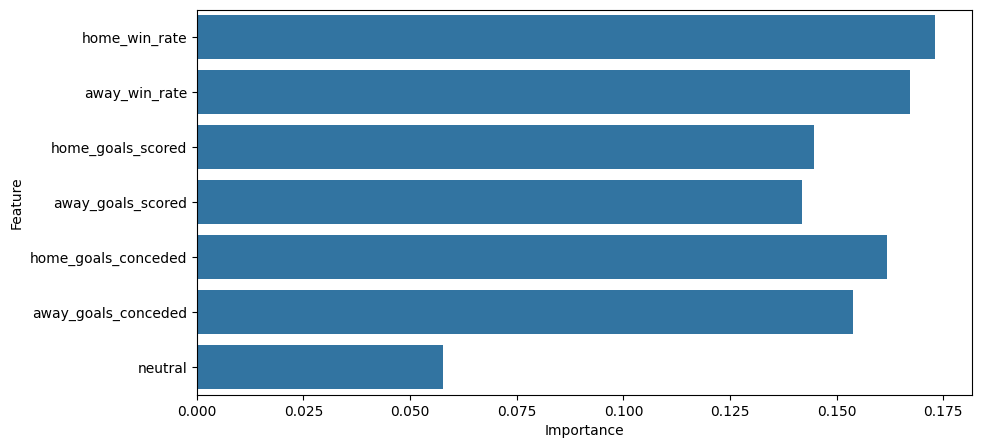

In [78]:
plt.figure(figsize=(10,5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.show()

In [79]:
def predict_match(home_team, away_team, neutral=True):

    home = team_stats[home_team]
    away = team_stats[away_team]

    data = pd.DataFrame({
        "home_win_rate":[home["win_rate"]],
        "away_win_rate":[away["win_rate"]],
        "home_goals_scored":[home["goals_scored"]],
        "away_goals_scored":[away["goals_scored"]],
        "home_goals_conceded":[home["goals_conceded"]],
        "away_goals_conceded":[away["goals_conceded"]],
        "neutral":[int(neutral)]
    })

    prediction = rf.predict(data)[0]

    if prediction == 0:
        return home_team
    elif prediction == 1:
        return away_team
    else:
        if home["win_rate"] >= away["win_rate"]:
            return home_team
        return away_team

In [80]:
predict_match("Argentina","Brazil")

'Argentina'

In [81]:
predict_match("France","England")

'England'

In [82]:
predict_match("Spain","Portugal")

'Spain'

In [83]:
predict_match("Germany","Netherlands")

'Germany'

In [84]:
round16 = [
    ("Argentina","Mexico"),
    ("Brazil","Japan"),
    ("France","Sweden"),
    ("England","United States"),
    ("Spain","Portugal"),
    ("Germany","Netherlands"),
    ("Belgium","Croatia"),
    ("Morocco","Switzerland")
]

In [85]:
quarterfinalists = []

for home, away in round16:
    winner = predict_match(home, away)
    print(f"{home} vs {away} → {winner}")
    quarterfinalists.append(winner)

Argentina vs Mexico → Argentina
Brazil vs Japan → Brazil
France vs Sweden → France
England vs United States → England
Spain vs Portugal → Spain
Germany vs Netherlands → Germany
Belgium vs Croatia → Croatia
Morocco vs Switzerland → Morocco


In [86]:
quarterfinals = []

for i in range(0, len(quarterfinalists), 2):
    quarterfinals.append(
        (
            quarterfinalists[i],
            quarterfinalists[i+1]
        )
    )

quarterfinals

[('Argentina', 'Brazil'),
 ('France', 'England'),
 ('Spain', 'Germany'),
 ('Croatia', 'Morocco')]

In [87]:
semifinalists = []

for home, away in quarterfinals:
    winner = predict_match(home, away)
    print(f"{home} vs {away} → {winner}")
    semifinalists.append(winner)

Argentina vs Brazil → Argentina
France vs England → England
Spain vs Germany → Spain
Croatia vs Morocco → Croatia


In [88]:
semifinals = [
    (semifinalists[0], semifinalists[1]),
    (semifinalists[2], semifinalists[3])
]

semifinals

[('Argentina', 'England'), ('Spain', 'Croatia')]

In [89]:
finalists = []

for home, away in semifinals:
    winner = predict_match(home, away)
    print(f"{home} vs {away} → {winner}")
    finalists.append(winner)

Argentina vs England → England
Spain vs Croatia → Spain


In [90]:
final = [
    (finalists[0], finalists[1])
]

final

[('England', 'Spain')]

In [91]:
champion = predict_match(final[0][0], final[0][1])

print("Predicted FIFA World Cup 2026 Champion")
print(champion)

Predicted FIFA World Cup 2026 Champion
Spain
